In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Reshape, Multiply

## Define SE Block again

In [ ]:
def se_block(input_tensor, reduction_ratio=16):
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Dense(filters // reduction_ratio, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([input_tensor, se])

## Rebuild the VGG-19 + SE Block Model

In [ ]:
input_tensor = Input(shape=(224, 224, 3))
base_model = VGG19(include_top=False, weights='imagenet', input_tensor=input_tensor)
x = base_model.output
x = se_block(x)
x = GlobalAveragePooling2D()(x)
model = Model(inputs=base_model.input, outputs=x)

## Grad-CAM Heatmap Generator

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv4', pred_index=None):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

## Image Loader

In [ ]:
def load_preprocessed_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array, img

## Display Heatmap on Original Image

In [ ]:
def display_gradcam(img_path, model, last_conv_layer_name='block5_conv4'):
    img_array, raw_img = load_preprocessed_image(img_path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    heatmap = cv2.resize(heatmap, (raw_img.size[0], raw_img.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(np.array(raw_img), 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original X-Ray")
    plt.imshow(raw_img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM Overlay")
    plt.imshow(superimposed)
    plt.axis('off')
    plt.show()

## Run on a Sample Image

C:\Users\shivs\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_44']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


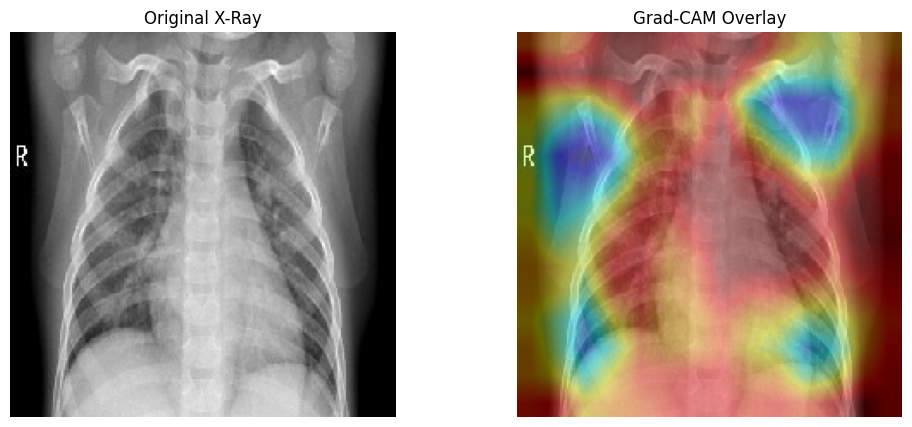

In [ ]:
# Example: pick any image from your dataset
sample_path = "Curated_X-Ray_Dataset/Pneumonia-Viral/Pneumonia-Viral (5).jpg"  # Change this to a real image path
display_gradcam(sample_path, model)

### Grad-CAM Overlay (Right):

* Grad-CAM (Gradient-weighted Class Activation Mapping) is a visual explainability technique used to interpret CNN-based models.

* The overlay on the X-ray highlights the regions of the image that the model focused on to make its prediction.

* Red and yellow areas indicate high attention, meaning the model considers these regions most important for predicting a disease class (like Bacterial Pneumonia, Viral Pneumonia, etc.).

* Blue regions indicate less attention, i.e., they were not significant in the decision-making process.